# POMDP Candidate Evaluation

This notebook evaluates the belief-limited attacker over the mixed `70/30` VAE candidate pool. It compares three observation-quality presets: `good_contact`, `baseline_night`, and `poor_contact`.

The selector only sees noisy attacker-facing observations and candidate parameters. It does not use true hit counts, expected loss, or full-state ranks while selecting candidates.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.realism import get_attacker_observation_config
from experiments.evaluate_attack_candidate_pool import evaluate_candidate_pool
from experiments.run_pomdp_candidate_selector import run_belief_selector


## Configuration

`good_contact` is the default realism preset. The full-state run path points at the latest mixed-VAE final baseline run, so the notebook can compute top-k overlap without rerunning the expensive oracle selector.


In [2]:
CANDIDATE_PATH = PROJECT_ROOT / "data" / "attack_profiles" / "vae_candidates" / "mixed_curated70_random30_hit_candidates.jsonl"
FULL_STATE_RUN_DIR = PROJECT_ROOT / "results" / "runs" / "candidate_pool_eval" / "20260512_144030_vae_final_baseline_mixed_vae"

OBSERVATION_PRESETS = ["good_contact", "baseline_night", "poor_contact"]
MAX_PROFILES = 1000
TOP_K = 25
SELECTION_SEED = 1945

RUN_SELECTION = True
RUN_MONTE_CARLO_EVAL = True

CONVOY_PROFILE = "convoy_layout_1"
EVAL_SEEDS = [1942, 1943, 1944]
N_TRIALS_PER_SEED = 10
T_MAX = 400.0
OBJECTIVE_CFG = {"preset": "balanced_default"}

OUTPUT_ROOT = Path("results/runs")


In [3]:
preset_rows = []
for preset in OBSERVATION_PRESETS:
    cfg = get_attacker_observation_config(preset)
    row = {"preset": preset}
    row.update(cfg.to_dict())
    preset_rows.append(row)

pd.DataFrame(preset_rows)


,preset,bearing_sigma_rad,range_sigma_m,heading_sigma_rad,speed_sigma_mps,contact_count_sigma,formation_width_sigma_m,formation_depth_sigma_m,class_count_sigma
0,good_contact,0.025,80.0,0.035,0.3,0.25,100.0,120.0,0.5
1,baseline_night,0.040,120.0,0.060,0.5,0.40,180.0,200.0,0.8
2,poor_contact,0.090,300.0,0.120,1.0,1.50,450.0,500.0,1.5


## Belief-Limited Selection

This cell ranks the mixed VAE candidate pool under each observation preset and writes a top-k JSONL candidate pool for each preset. Those JSONL files are the bridge into the existing Monte Carlo evaluator.


In [4]:
selection_dirs: dict[str, Path] = {}

if RUN_SELECTION:
    for preset in OBSERVATION_PRESETS:
        run_dir = run_belief_selector(
            candidate_path=CANDIDATE_PATH,
            project_root=PROJECT_ROOT,
            output_root=OUTPUT_ROOT,
            run_name=f"pomdp_{preset}_notebook",
            convoy_profile=CONVOY_PROFILE,
            max_profiles=MAX_PROFILES,
            top_k=TOP_K,
            seed=SELECTION_SEED,
            observation_preset=preset,
        )
        selection_dirs[preset] = run_dir
        print(f"{preset}: {run_dir}")
else:
    selection_dirs = {
        # "good_contact": PROJECT_ROOT / "results/runs/pomdp_candidate_selector/<existing_good_contact_run>",
        # "baseline_night": PROJECT_ROOT / "results/runs/pomdp_candidate_selector/<existing_baseline_night_run>",
        # "poor_contact": PROJECT_ROOT / "results/runs/pomdp_candidate_selector/<existing_poor_contact_run>",
    }

selection_dirs


good_contact: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260611_012420_pomdp_good_contact_notebook
baseline_night: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260611_012420_pomdp_baseline_night_notebook
poor_contact: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260611_012420_pomdp_poor_contact_notebook


{'good_contact': PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260611_012420_pomdp_good_contact_notebook'),
 'baseline_night': PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260611_012420_pomdp_baseline_night_notebook'),
 'poor_contact': PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260611_012420_pomdp_poor_contact_notebook')}

In [5]:
belief_tables = []
for preset, run_dir in selection_dirs.items():
    df = pd.read_csv(run_dir / "belief_ranked_candidates.csv")
    df.insert(0, "preset", preset)
    belief_tables.append(df)

belief_df = pd.concat(belief_tables, ignore_index=True) if belief_tables else pd.DataFrame()
belief_df.head(10)


,preset,profile_id,name,belief_score,u_pos_x,u_pos_y,estimated_range_m,estimated_bearing_rad,estimated_convoy_heading_rad,estimated_convoy_speed_mps,...,spawn_region,approach_side,inside_convoy_envelope,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps,candidate_source_label,selector_method,belief_rank
0,good_contact,VAE000281,vae_candidate_000281,1.044843,15.973389,2474.280518,2613.901764,-1.579527,0.012539,5.083983,...,inside_convoy_envelope,inside,True,0.079132,0.757271,2.959125,1.536345,vae_candidate_pool_v1,belief_limited_heuristic_v1,1
1,good_contact,VAE000766,vae_candidate_000766,1.044374,-143.002197,-2080.208984,2117.297682,1.536255,0.028197,5.127939,...,inside_convoy_envelope,inside,True,0.098095,0.858272,2.094674,1.110730,vae_candidate_pool_v1,belief_limited_heuristic_v1,2
2,good_contact,VAE000270,vae_candidate_000270,1.043602,-244.955566,2109.702148,2091.093428,-1.463658,-0.013843,4.874882,...,inside_convoy_envelope,inside,True,0.089185,0.717871,2.968292,1.107509,vae_candidate_pool_v1,belief_limited_heuristic_v1,3
3,good_contact,VAE001091,vae_candidate_001091,1.043104,261.502441,2069.897461,2143.224740,-1.712248,0.006820,5.144807,...,inside_convoy_envelope,inside,True,0.093518,0.880318,2.317576,1.786740,vae_candidate_pool_v1,belief_limited_heuristic_v1,4
4,good_contact,VAE000317,vae_candidate_000317,1.040627,-0.086975,-2315.433350,2266.912207,1.581634,-0.011312,5.481033,...,inside_convoy_envelope,inside,True,0.067213,1.078404,1.524865,1.135609,vae_candidate_pool_v1,belief_limited_heuristic_v1,5
5,good_contact,VAE000784,vae_candidate_000784,1.040052,-53.651703,1966.689453,2037.933993,-1.532476,-0.031373,4.911635,...,inside_convoy_envelope,inside,True,0.078042,1.074685,1.505718,1.673887,vae_candidate_pool_v1,belief_limited_heuristic_v1,6
6,good_contact,VAE000974,vae_candidate_000974,1.038074,-349.065979,-2042.093262,2174.751864,1.432701,-0.039999,4.989385,...,inside_convoy_envelope,inside,True,0.066432,1.088156,1.510129,1.124873,vae_candidate_pool_v1,belief_limited_heuristic_v1,7
7,good_contact,VAE000459,vae_candidate_000459,1.033828,-42.739777,2334.523193,2504.271724,-1.595510,-0.053491,4.811984,...,inside_convoy_envelope,inside,True,0.065248,0.887902,1.519199,1.145162,vae_candidate_pool_v1,belief_limited_heuristic_v1,8
8,good_contact,VAE000685,vae_candidate_000685,1.032303,375.302795,2475.170410,2429.597450,-1.690118,-0.009163,4.479612,...,inside_convoy_envelope,inside,True,0.054745,2.041266,1.482999,1.054845,vae_candidate_pool_v1,belief_limited_heuristic_v1,9
9,good_contact,VAE000009,vae_candidate_000009,1.031639,154.159698,-2216.000000,2276.640546,1.653399,-0.008811,5.085192,...,inside_convoy_envelope,inside,True,0.047894,2.276132,2.054655,1.583893,vae_candidate_pool_v1,belief_limited_heuristic_v1,10


## Evaluate Selected Top-K Candidates

Each preset's selected top-k candidate pool is evaluated with the same scored Monte Carlo pipeline used by the full-state attacker baseline.


In [6]:
eval_dirs: dict[str, Path] = {}

if RUN_MONTE_CARLO_EVAL:
    for preset, selection_dir in selection_dirs.items():
        selected_pool = selection_dir / "top_belief_candidate_pool.jsonl"
        run_dir = evaluate_candidate_pool(
            candidate_path=selected_pool,
            project_root=PROJECT_ROOT,
            output_root=OUTPUT_ROOT,
            run_name=f"pomdp_{preset}_top{TOP_K}_eval_notebook",
            convoy_profile=CONVOY_PROFILE,
            max_profiles=None,
            top_k=TOP_K,
            seeds=EVAL_SEEDS,
            n_trials_per_seed=N_TRIALS_PER_SEED,
            t_max=T_MAX,
            max_hits_per_torpedo=1,
            objective_cfg=OBJECTIVE_CFG,
        )
        eval_dirs[preset] = run_dir
        print(f"{preset}: {run_dir}")
else:
    eval_dirs = {
        # "good_contact": PROJECT_ROOT / "results/runs/candidate_pool_eval/<existing_good_contact_eval>",
        # "baseline_night": PROJECT_ROOT / "results/runs/candidate_pool_eval/<existing_baseline_night_eval>",
        # "poor_contact": PROJECT_ROOT / "results/runs/candidate_pool_eval/<existing_poor_contact_eval>",
    }

eval_dirs


good_contact: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260611_012420_pomdp_good_contact_top25_eval_notebook
baseline_night: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260611_012425_pomdp_baseline_night_top25_eval_notebook
poor_contact: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260611_012431_pomdp_poor_contact_top25_eval_notebook


{'good_contact': PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260611_012420_pomdp_good_contact_top25_eval_notebook'),
 'baseline_night': PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260611_012425_pomdp_baseline_night_top25_eval_notebook'),
 'poor_contact': PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260611_012431_pomdp_poor_contact_top25_eval_notebook')}

## Summary Table

For POMDP rows, `candidate_pool` is the belief-selected top-k pool. For the optional full-state row, `top_k` is the oracle-selected top-k from the existing full-state mixed-VAE baseline.


In [7]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

summary_rows = []

if FULL_STATE_RUN_DIR.exists():
    metrics = load_json(FULL_STATE_RUN_DIR / "metrics_summary.json")
    top = metrics["top_k"]
    best = metrics.get("best_candidate") or {}
    summary_rows.append({
        "selector": "full_state_oracle",
        "preset": "oracle",
        "profiles": int(top.get("profiles", TOP_K)),
        "expected_hits": float(top["expected_hits"]),
        "expected_loss": float(top.get("expected_loss", 0.0)),
        "expected_unique_ships_hit": float(top.get("expected_unique_ships_hit", 0.0)),
        "CVaR_90": float(top.get("CVaR_90", 0.0)),
        "CVaR_90_loss": float(top.get("CVaR_90_loss", 0.0)),
        "best_profile_id": str(best.get("profile_id", "")),
    })

for preset, run_dir in eval_dirs.items():
    metrics = load_json(run_dir / "metrics_summary.json")
    pool = metrics["candidate_pool"]
    best = metrics.get("best_candidate") or {}
    summary_rows.append({
        "selector": "belief_limited",
        "preset": preset,
        "profiles": int(pool.get("profiles", TOP_K)),
        "expected_hits": float(pool["expected_hits"]),
        "expected_loss": float(pool.get("expected_loss", 0.0)),
        "expected_unique_ships_hit": float(pool.get("expected_unique_ships_hit", 0.0)),
        "CVaR_90": float(pool.get("CVaR_90", 0.0)),
        "CVaR_90_loss": float(pool.get("CVaR_90_loss", 0.0)),
        "best_profile_id": str(best.get("profile_id", "")),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,selector,preset,profiles,expected_hits,expected_loss,expected_unique_ships_hit,CVaR_90,CVaR_90_loss,best_profile_id
0,full_state_oracle,oracle,25,3.850667,6.607333,3.180000,3.960000,6.880000,VAE000124
1,belief_limited,good_contact,25,3.364000,4.020600,1.826667,3.481333,4.444800,VAE000317
2,belief_limited,baseline_night,25,3.440000,4.104867,1.864000,3.561333,4.534800,VAE000317
3,belief_limited,poor_contact,25,3.428000,4.091133,1.857333,3.641333,4.644514,VAE000317


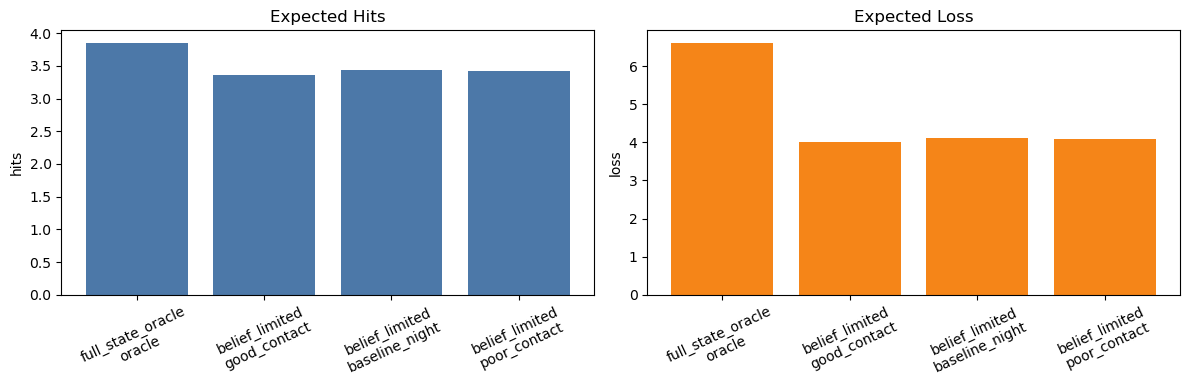

In [8]:
if len(summary_df):
    plot_df = summary_df.copy()
    plot_df["label"] = plot_df["selector"] + "\n" + plot_df["preset"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="white")
    axes[0].bar(plot_df["label"], plot_df["expected_hits"], color="#4c78a8")
    axes[0].set_title("Expected Hits")
    axes[0].set_ylabel("hits")
    axes[0].tick_params(axis="x", rotation=25)
    axes[1].bar(plot_df["label"], plot_df["expected_loss"], color="#f58518")
    axes[1].set_title("Expected Loss")
    axes[1].set_ylabel("loss")
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()


## Rank Overlap With Full-State Oracle

This checks whether noisy belief selection is choosing the same candidates as the full-state Monte Carlo oracle. Lower overlap is expected as observation quality degrades.


In [9]:
overlap_rows = []
if FULL_STATE_RUN_DIR.exists() and selection_dirs:
    full_ranked = pd.read_csv(FULL_STATE_RUN_DIR / "ranked_candidates.csv")
    oracle_top = set(full_ranked.head(TOP_K)["profile_id"].astype(str))
    for preset, run_dir in selection_dirs.items():
        belief_ranked = pd.read_csv(run_dir / "belief_ranked_candidates.csv")
        belief_top = set(belief_ranked.head(TOP_K)["profile_id"].astype(str))
        overlap_rows.append({
            "preset": preset,
            "top_k": TOP_K,
            "overlap_count": len(oracle_top & belief_top),
            "overlap_rate": len(oracle_top & belief_top) / float(TOP_K),
        })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df


,preset,top_k,overlap_count,overlap_rate
0,good_contact,25,1,0.04
1,baseline_night,25,2,0.08
2,poor_contact,25,2,0.08


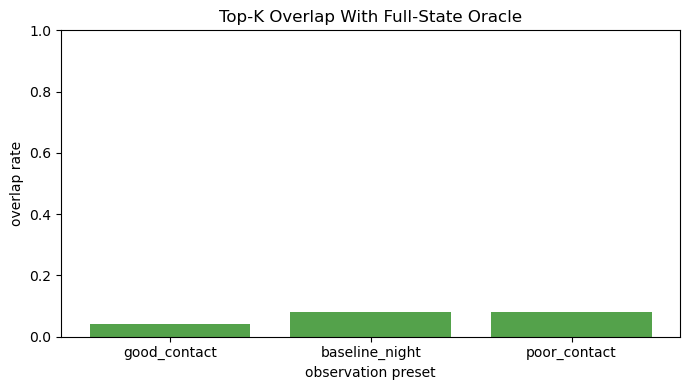

In [10]:
if len(overlap_df):
    fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
    ax.bar(overlap_df["preset"], overlap_df["overlap_rate"], color="#54a24b")
    ax.set_ylim(0, 1)
    ax.set_title("Top-K Overlap With Full-State Oracle")
    ax.set_ylabel("overlap rate")
    ax.set_xlabel("observation preset")
    plt.tight_layout()
    plt.show()
